<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/notebooks/colab/Day_12_ZebraMap_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SetUp**

In [1]:
from google.colab import drive, userdata
import os, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from datetime import datetime

drive.mount('/content/drive')

try:
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
except:
    pass

BASE    = "/content/drive/MyDrive/rare_disease_project"
DATA    = f"{BASE}/data"
RESULTS = f"{BASE}/results"
MODELS  = f"{BASE}/models"
GAN_DIR = f"{BASE}/gan"

os.makedirs(f"{GAN_DIR}/zebra_checkpoints", exist_ok=True)
os.makedirs(f"{GAN_DIR}/zebra_generated",   exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {torch.cuda.get_device_name(0)}")

# Load dataset
df = pd.read_csv(f"{DATA}/clean_multimodal_samples.csv")
new_le = LabelEncoder()
df['label'] = new_le.fit_transform(df['disease_name'])
print(f"✓ Dataset loaded: {df.shape}")

Mounted at /content/drive
✓ Device: Tesla T4
✓ Dataset loaded: (36487, 10)


# **Analyze Image Subtypes Per Class**

In [2]:
import ast

# Parse image subtypes
def get_subtypes(img_str):
    try:
        imgs = img_str if isinstance(img_str, list) \
                       else eval(img_str)
        return [img.get('subtype', 'Unknown') for img in imgs]
    except:
        return []

def get_first_subtype(img_str):
    subtypes = get_subtypes(img_str)
    return subtypes[0] if subtypes else 'Unknown'

df['primary_subtype'] = df['images'].apply(get_first_subtype)

# Class counts
class_counts = df.groupby(
    ['label', 'disease_name']).size().reset_index(name='count')

# Ultra-rare classes with 5-20 samples
gan_targets = class_counts[
    (class_counts['count'] >= 5) &
    (class_counts['count'] <= 20)
].reset_index(drop=True)

print(f"✓ GAN targets: {len(gan_targets)} classes (5-20 samples)")

# Subtype distribution in GAN targets
target_labels  = set(gan_targets['label'].tolist())
target_df      = df[df['label'].isin(target_labels)]
subtype_counts = target_df['primary_subtype'].value_counts()

print(f"\nTop image subtypes in GAN target classes:")
print(subtype_counts.head(15).to_string())

# Group classes by dominant subtype
subtype_groups = {}
for label in target_labels:
    cls_df   = df[df['label'] == label]
    subtypes = cls_df['primary_subtype'].value_counts()
    dominant = subtypes.index[0] if len(subtypes) > 0 else 'Unknown'
    if dominant not in subtype_groups:
        subtype_groups[dominant] = []
    subtype_groups[dominant].append(label)

print(f"\nSubtype groups for GAN training:")
for subtype, labels in sorted(
        subtype_groups.items(),
        key=lambda x: -len(x[1]))[:10]:
    print(f"  {subtype:<35}: {len(labels)} classes")

✓ GAN targets: 474 classes (5-20 samples)

Top image subtypes in GAN target classes:
primary_subtype
MRI                                    554
CT Scan                                313
Radiography                            282
Dermatology Imaging                    238
Histopathology                         231
Ultrasound                             160
General Imaging                        160
Diagnostic Imaging                     111
X-ray                                  108
Fundus Photography                      91
Histopathology and Cytology Imaging     90
Genetic Analysis                        77
Dermatological Imaging                  71
Facial Imaging                          70
Pediatric Imaging                       65

Subtype groups for GAN training:
  MRI                                : 88 classes
  CT Scan                            : 40 classes
  Radiography                        : 39 classes
  Dermatology Imaging                : 33 classes
  Histopathology    

# **FastGAN Architecture**

In [3]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ch)
        )
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(x + self.conv(x))


class FastGANGenerator(nn.Module):
    def __init__(self, nz=128, ngf=64):
        super().__init__()
        self.nz   = nz
        self.init = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True)
        )
        self.up = nn.Sequential(
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True), ResBlock(ngf*4),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True), ResBlock(ngf*2),
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),   nn.ReLU(True), ResBlock(ngf),
            nn.ConvTranspose2d(ngf, 3,       4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.up(self.init(z.view(-1, self.nz, 1, 1)))


class FastGANDiscriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        def blk(ic, oc):
            return nn.Sequential(
                nn.utils.spectral_norm(
                    nn.Conv2d(ic, oc, 4, 2, 1, bias=False)),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.net = nn.Sequential(
            blk(3, ndf), blk(ndf, ndf*2),
            blk(ndf*2, ndf*4), blk(ndf*4, ndf*8),
            nn.Conv2d(ndf*8, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)


NZ = 128
print(f"✓ FastGAN architecture ready (64×64)")

✓ FastGAN architecture ready (64×64)


# **Subtype-Grouped GAN Dataset**

In [4]:
class SubtypeGANDataset(Dataset):
    """Dataset grouping images by subtype for better GAN training"""
    def __init__(self, df, labels, subtype,
                 img_size=64, max_images=200):
        self.samples   = []
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        for label in labels:
            cls_df = df[df['label'] == label]
            for _, row in cls_df.iterrows():
                try:
                    imgs = row['images'] \
                        if isinstance(row['images'], list) \
                        else eval(row['images'])
                    for img_info in imgs:
                        # Filter by subtype
                        if img_info.get('subtype',
                                        '') == subtype:
                            path = img_info['path']
                            if os.path.exists(path):
                                self.samples.append({
                                    'path' : path,
                                    'label': label
                                })
                except:
                    continue

        # Cap at max_images to keep training fast
        if len(self.samples) > max_images:
            import random
            random.shuffle(self.samples)
            self.samples = self.samples[:max_images]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        try:
            img = Image.open(
                self.samples[idx]['path']).convert('RGB')
            return self.transform(img)
        except:
            return torch.zeros(3, 64, 64)


def train_gan_fast(G, D, loader, device,
                   epochs=300, nz=128, lr=2e-4):
    """Faster GAN training for ZebraMap"""
    opt_G = Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(epochs):
        for real in loader:
            real = real.to(device)
            bs   = real.size(0)

            # D step
            opt_D.zero_grad()
            z    = torch.randn(bs, nz).to(device)
            d_l  = (F.relu(1.0 - D(real)).mean() +
                    F.relu(1.0 + D(G(z).detach())).mean())
            d_l.backward()
            opt_D.step()

            # G step
            opt_G.zero_grad()
            z    = torch.randn(bs, nz).to(device)
            g_l  = -D(G(z)).mean()
            g_l.backward()
            opt_G.step()

        if (epoch + 1) % 100 == 0:
            print(f"    Epoch {epoch+1}/{epochs} | "
                  f"G: {g_l.item():.3f} | "
                  f"D: {d_l.item():.3f}")

print("✓ Training function ready")

✓ Training function ready


# **Train GAN Per Subtype Group**

In [5]:
# Select top 5 subtype groups with most classes
top_subtypes = sorted(
    subtype_groups.items(),
    key=lambda x: -len(x[1])
)[:5]

print("Training GAN on top 5 subtype groups:")
for st, labs in top_subtypes:
    print(f"  {st:<35}: {len(labs)} classes")

gan_generators = {}
generation_log = {}

for subtype, labels in top_subtypes:
    print(f"\n{'='*50}")
    print(f"Subtype: {subtype} ({len(labels)} classes)")
    print(f"{'='*50}")

    dataset = SubtypeGANDataset(
        df, labels, subtype,
        img_size=64, max_images=200
    )

    if len(dataset) < 5:
        print(f"  ✗ Skipping — only {len(dataset)} images")
        continue

    loader = DataLoader(dataset, batch_size=16,
                        shuffle=True, num_workers=2)

    G = FastGANGenerator(nz=NZ, ngf=64).to(device)
    D = FastGANDiscriminator(ndf=64).to(device)

    print(f"  Real images : {len(dataset)}")
    train_gan_fast(G, D, loader, device,
                   epochs=300, nz=NZ)

    # Save checkpoint
    safe_name = subtype.replace(' ', '_').replace('/', '_')
    ckpt_path = f"{GAN_DIR}/zebra_checkpoints/G_{safe_name}.pt"
    torch.save(G.state_dict(), ckpt_path)

    gan_generators[subtype] = G
    generation_log[subtype] = {
        'classes'    : len(labels),
        'real_images': len(dataset),
        'checkpoint' : ckpt_path
    }
    print(f"  ✓ Saved: G_{safe_name}.pt")

print(f"\n✓ All GAN models trained: {len(gan_generators)}")

Training GAN on top 5 subtype groups:
  MRI                                : 88 classes
  CT Scan                            : 40 classes
  Radiography                        : 39 classes
  Dermatology Imaging                : 33 classes
  Histopathology                     : 29 classes

Subtype: MRI (88 classes)
  Real images : 200
    Epoch 100/300 | G: 0.596 | D: 1.596
    Epoch 200/300 | G: 0.303 | D: 1.554
    Epoch 300/300 | G: 0.591 | D: 0.840
  ✓ Saved: G_MRI.pt

Subtype: CT Scan (40 classes)
  Real images : 200
    Epoch 100/300 | G: -0.104 | D: 1.963
    Epoch 200/300 | G: 0.452 | D: 1.446
    Epoch 300/300 | G: 0.937 | D: 0.463
  ✓ Saved: G_CT_Scan.pt

Subtype: Radiography (39 classes)
  Real images : 200
    Epoch 100/300 | G: 0.169 | D: 2.170
    Epoch 200/300 | G: 0.232 | D: 2.047
    Epoch 300/300 | G: 0.651 | D: 1.243
  ✓ Saved: G_Radiography.pt

Subtype: Dermatology Imaging (33 classes)
  Real images : 181
    Epoch 100/300 | G: 0.036 | D: 2.026
    Epoch 200/300 | G: 

# **Generate + Save Synthetic Images**

In [6]:
TARGET_PER_CLASS = 20  # Generate 20 synthetic per ultra-rare class

total_generated = 0

for subtype, labels in top_subtypes:
    if subtype not in gan_generators:
        continue

    G = gan_generators[subtype]
    G.eval()

    for label in labels:
        disease_name = df[df['label'] == label][
            'disease_name'].iloc[0]
        safe_name    = disease_name.replace(
            ' ', '_').replace('/', '_')[:30]
        save_dir     = f"{GAN_DIR}/zebra_generated/{safe_name}"
        os.makedirs(save_dir, exist_ok=True)

        with torch.no_grad():
            z    = torch.randn(
                TARGET_PER_CLASS, NZ).to(device)
            imgs = G(z)
            imgs = (imgs * 0.5 + 0.5).clamp(0, 1)

        for i, img in enumerate(imgs):
            from torchvision.transforms.functional import to_pil_image
            pil = to_pil_image(img.cpu())
            pil.save(f"{save_dir}/gan_{i:03d}.jpg")

        total_generated += TARGET_PER_CLASS

    print(f"  ✓ {subtype[:35]}: "
          f"generated {TARGET_PER_CLASS} × "
          f"{len(labels)} classes")

print(f"\n✓ Total images generated: {total_generated}")

  ✓ MRI: generated 20 × 88 classes
  ✓ CT Scan: generated 20 × 40 classes
  ✓ Radiography: generated 20 × 39 classes
  ✓ Dermatology Imaging: generated 20 × 33 classes
  ✓ Histopathology: generated 20 × 29 classes

✓ Total images generated: 4580


# **Visualize Generated Images by Subtype**

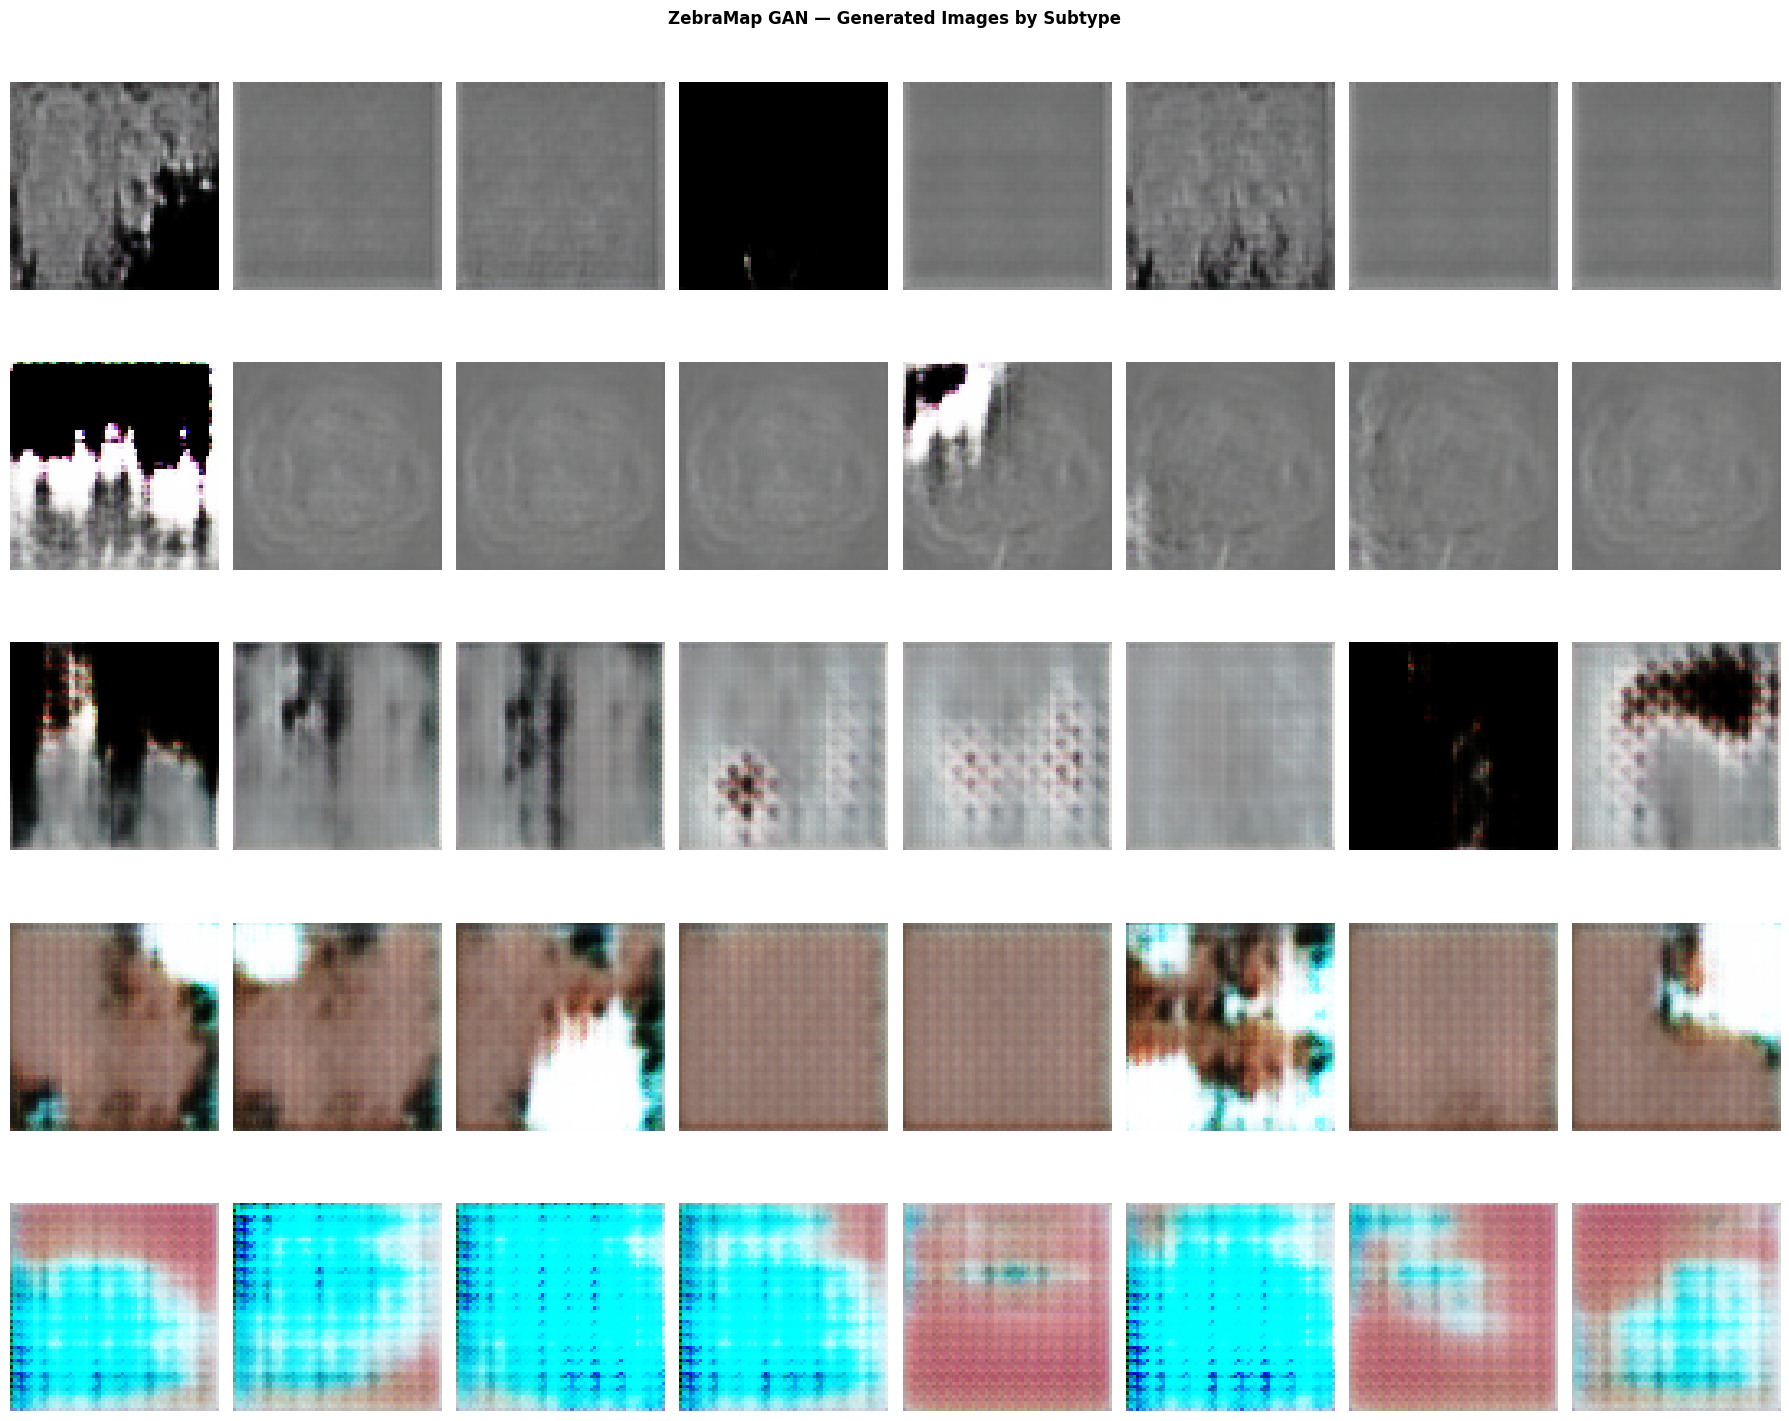

✓ Visualization saved


In [7]:
fig, big_axes = plt.subplots(
    len(gan_generators), 8,
    figsize=(18, 3 * len(gan_generators))
)

if len(gan_generators) == 1:
    big_axes = [big_axes]

for row_idx, (subtype, G) in enumerate(
        gan_generators.items()):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(8, NZ).to(device)
        imgs = G(z)
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)

    for col_idx in range(8):
        ax  = big_axes[row_idx][col_idx]
        img = imgs[col_idx].cpu().permute(
            1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(subtype[:20], fontsize=7,
                          rotation=0, labelpad=70,
                          va='center')

plt.suptitle(
    'ZebraMap GAN — Generated Images by Subtype',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{RESULTS}/day12_zebra_generated.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("✓ Visualization saved")

# **Save Summary**

In [8]:
summary = {
    "day"            : 12,
    "experiment"     : "exp5_zebramap_gan",
    "approach"       : "Subtype-grouped GAN training",
    "subtypes_trained": len(gan_generators),
    "target_per_class": TARGET_PER_CLASS,
    "total_generated" : total_generated,
    "generation_log"  : {
        k: {
            'classes'    : int(v['classes']),
            'real_images': int(v['real_images'])
        }
        for k, v in generation_log.items()
    },
    "status": "Day 12 complete"
}

with open(f"{RESULTS}/day12_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 55)
print("DAY 12 COMPLETE ✓")
print("=" * 55)
print(f"  Approach       : Subtype-grouped GAN")
print(f"  Subtypes       : {len(gan_generators)}")
print(f"  Total generated: {total_generated} images")
print(f"\n  Generation log:")
for st, info in generation_log.items():
    print(f"    {st[:35]:<35}: "
          f"{info['classes']} classes × "
          f"{TARGET_PER_CLASS} = "
          f"{info['classes']*TARGET_PER_CLASS} imgs")
print(f"\n  Next → Day 13: Retrain ZebraMap with GAN data")

DAY 12 COMPLETE ✓
  Approach       : Subtype-grouped GAN
  Subtypes       : 5
  Total generated: 4580 images

  Generation log:
    MRI                                : 88 classes × 20 = 1760 imgs
    CT Scan                            : 40 classes × 20 = 800 imgs
    Radiography                        : 39 classes × 20 = 780 imgs
    Dermatology Imaging                : 33 classes × 20 = 660 imgs
    Histopathology                     : 29 classes × 20 = 580 imgs

  Next → Day 13: Retrain ZebraMap with GAN data
